In [11]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

In [12]:
df['job_posted_month']=df['job_posted_date'].dt.strftime('%B')

In [13]:
df_us_pivot=df[df['job_location']=='United States'].pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

In [14]:
df_us_pivot.reset_index(inplace=True)

In [15]:
df_us_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,NaN,1.0,12.0,66.0,393.0,7.0,3.0,18.0,93.0,1.0
1,August,1.0,1.0,9.0,123.0,439.0,5.0,5.0,25.0,168.0,4.0
2,December,1.0,NaN,42.0,114.0,267.0,11.0,7.0,28.0,47.0,6.0
3,February,1.0,1.0,7.0,109.0,356.0,3.0,2.0,30.0,78.0,1.0
4,January,NaN,NaN,8.0,150.0,413.0,5.0,4.0,36.0,104.0,3.0
5,July,1.0,NaN,13.0,70.0,302.0,NaN,2.0,17.0,62.0,4.0
6,June,NaN,2.0,10.0,68.0,268.0,4.0,1.0,25.0,53.0,2.0
7,March,2.0,2.0,9.0,83.0,368.0,2.0,2.0,26.0,86.0,3.0
8,May,NaN,1.0,8.0,97.0,410.0,6.0,2.0,23.0,79.0,3.0
9,November,4.0,NaN,40.0,137.0,349.0,17.0,7.0,31.0,78.0,10.0


In [16]:
df_us_pivot['month_no']=pd.to_datetime(df_us_pivot['job_posted_month'], format='%B').dt.month

In [20]:

df_us_pivot.sort_index(inplace=True)

In [21]:
df_us_pivot.set_index('job_posted_month', inplace=True)

In [25]:
df_us_software_pivot=pd.read_csv('https://lukeb.co/software_csv',index_col='job_posted_month')

In [27]:
df_merge=df_us_pivot.merge(df_us_software_pivot, on='job_posted_month')

In [28]:
top5=df_merge.sum().sort_values(ascending=False).head(5).index.tolist()

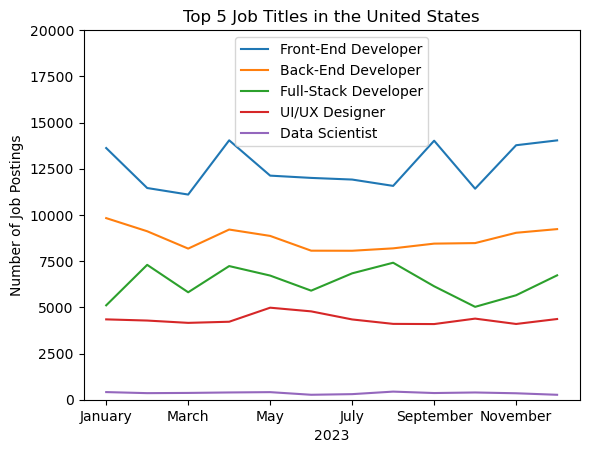

: 

In [ ]:
df_merge[top5].plot(kind='line')
plt.title('Top 5 Job Titles in the United States')
plt.xlabel('2023')
plt.ylabel('Number of Job Postings')
plt.ylim(0, 20000)
plt.legend()
plt.show()
